# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_1923/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

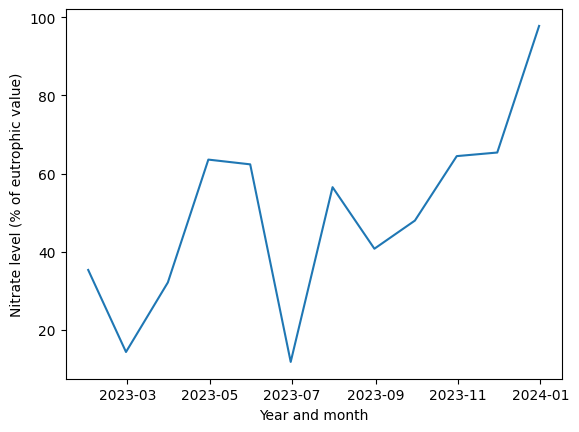

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_1923/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

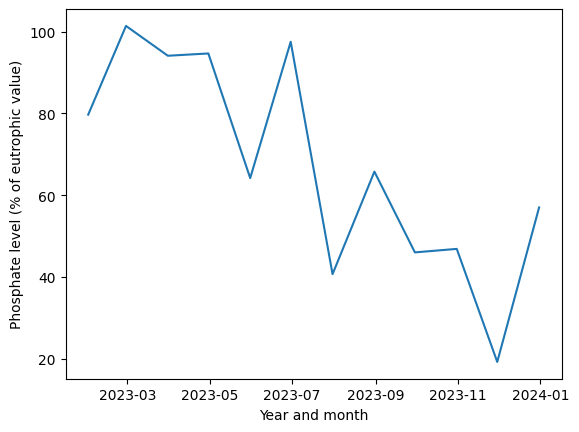

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

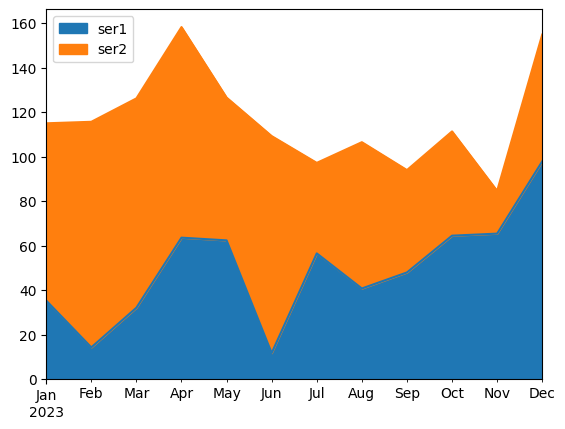

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Advantages of an area plot include that it shows total magnitude visually and if stacked, the viewer can quickly see the combined nutrient load in the water sample. The plot is also good for emphasizing volume and the filled area visually communicates how much nutrient is present overall. The visual is also compact allowing for easy comprehension of how the composition changes over time. 

Some disadvantages of an area plot include it is harder to compare individual trends. Additionally, the overlap can obscure patterns and may imply cumulative meaning.

Advantages of two separate line graphs include that is a clear representation of individual trends over time, there is no visual distortion from stacking, and overall it is better  for scientific interpretation.


Disadvantages of two separate line graphs include that it is harder to compare relationships and it uses more space.

The graphs can be improved by incorporating the following:
1. Plot both nutrients on the same line chart. This allows direct comparison without stacking distortion.
2. Use transparency (alpha) so both nutrients remain visible. 
3. Label the legend clearly
4. Add a meaningful title
5. Environmental context improvements, like adding a horizontal reference line showing the eutrophic threshold
6. Use distinct colors (e.g., blue for nitrate, green for phosphate)


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [7]:
import os
import pandas as pd

# Create data folder if it doesn't exist
os.makedirs("./data", exist_ok=True)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 160k/160k [00:00<00:00, 20.3MB/s]

Extracting files...
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1


In [11]:
import os
import pandas as pd

# Path where kagglehub extracted the files
dataset_path = "/home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1"

# Automatically find the first CSV
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the dataset folder!")

csv_file = os.path.join(dataset_path, csv_files[0])

# Load CSV with ISO-8859-1 encoding
df = pd.read_csv(csv_file, encoding='ISO-8859-1')

# Quick check
print(f"Loaded dataset: {csv_file}")
print("Dataset shape:", df.shape)
print(df.head())

Loaded dataset: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1/US  E-commerce records 2020.csv
Dataset shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United States     Franklin   Wisconsin        53132  Central   
3  United States   Huntsville       Texas        77340  Central   
4  United Stat

Dataset shape: (3312, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Pr

/tmp/ipykernel_1923/1713779114.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], errors='coerce')


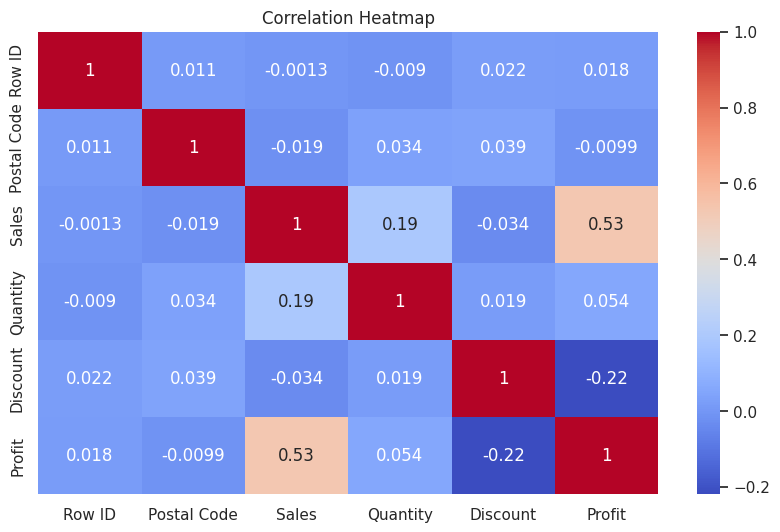

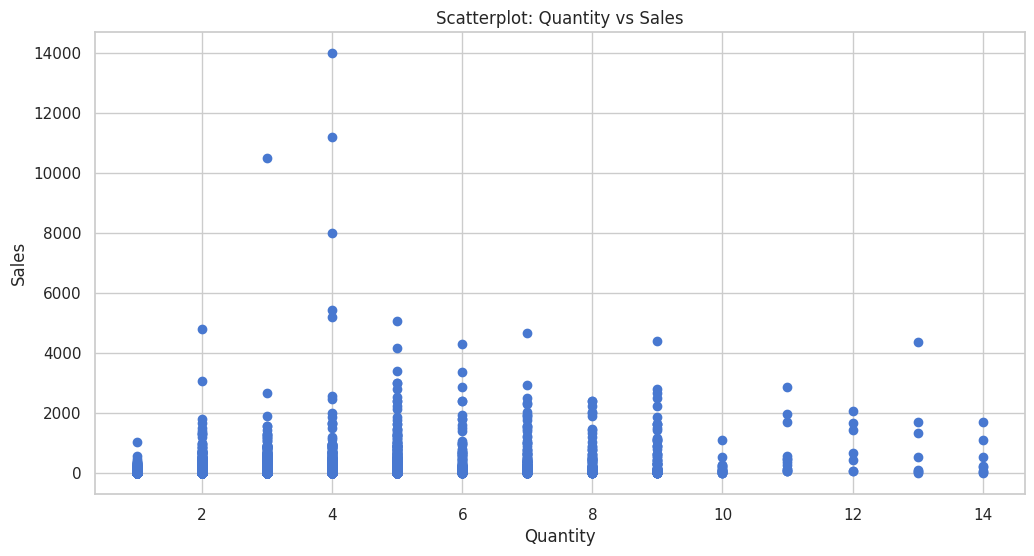

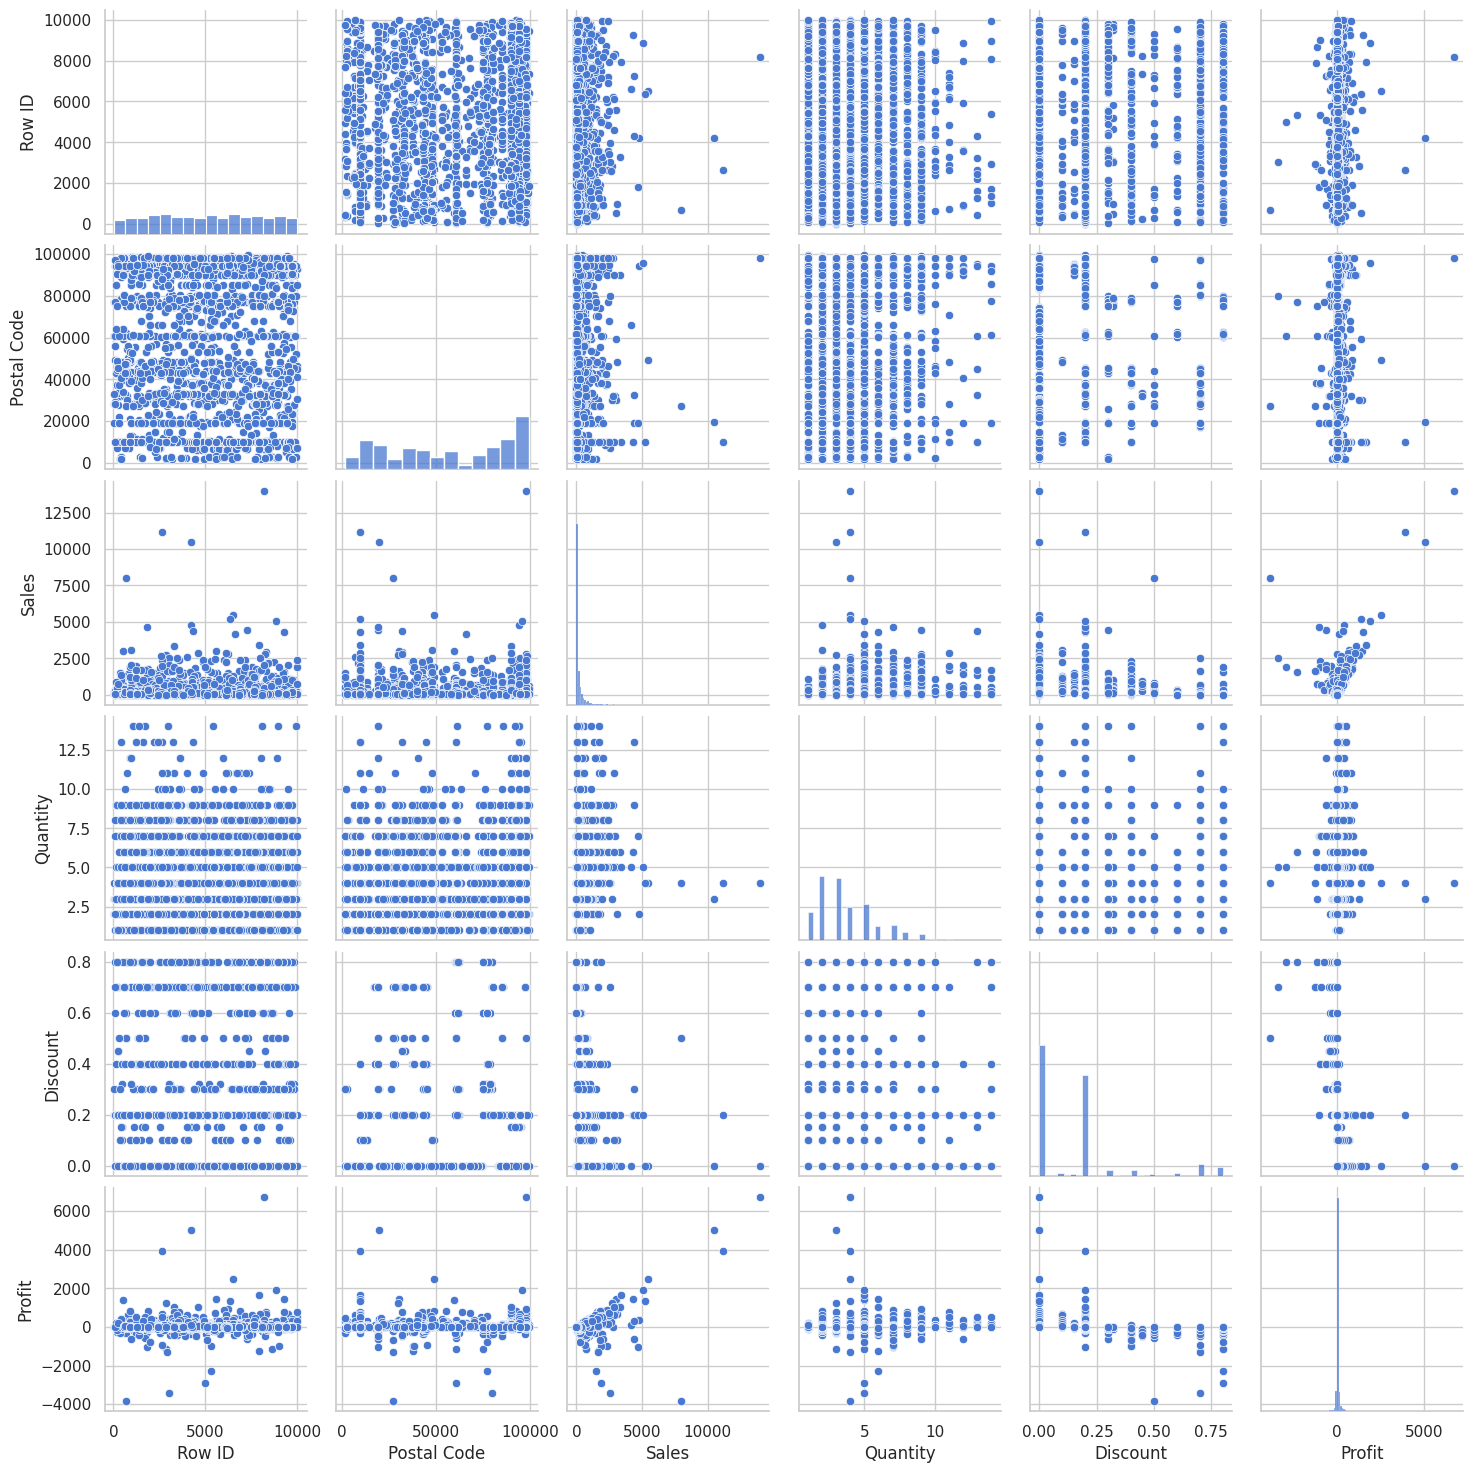

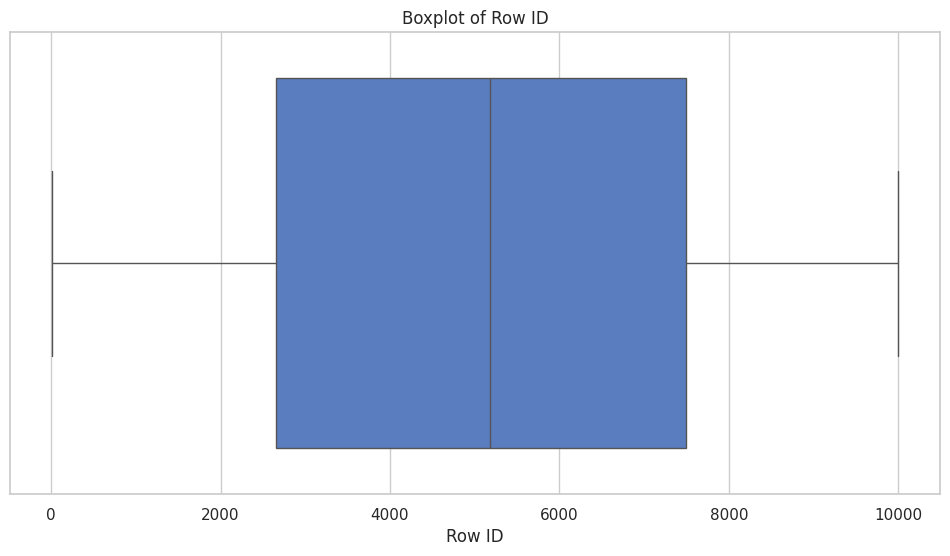

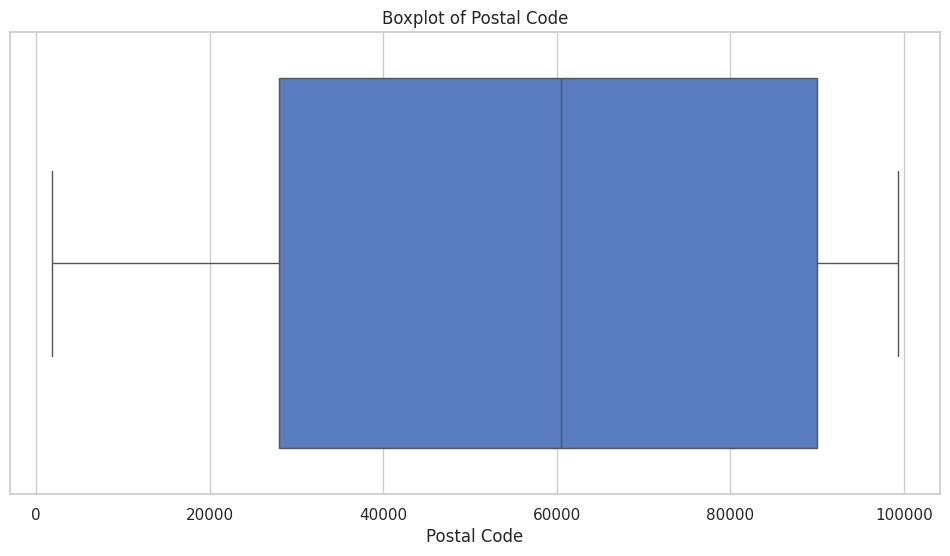

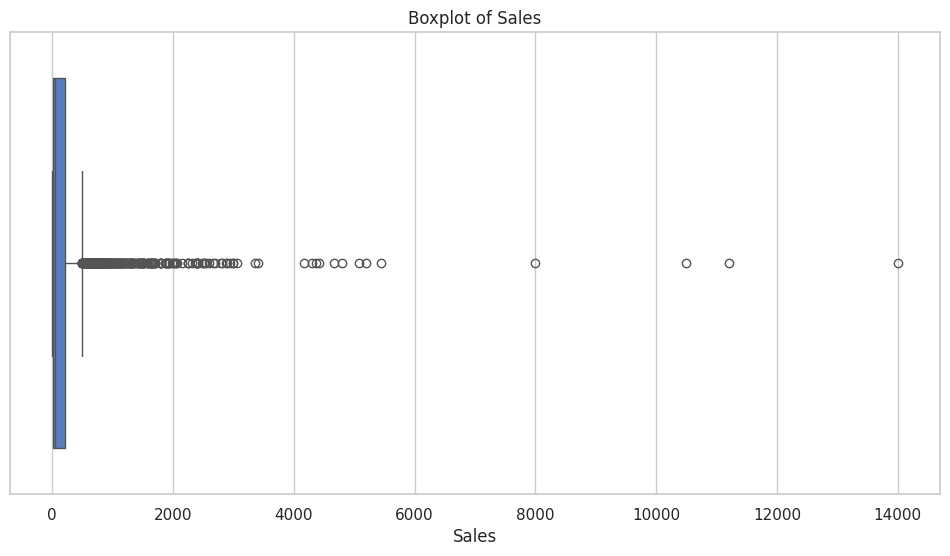

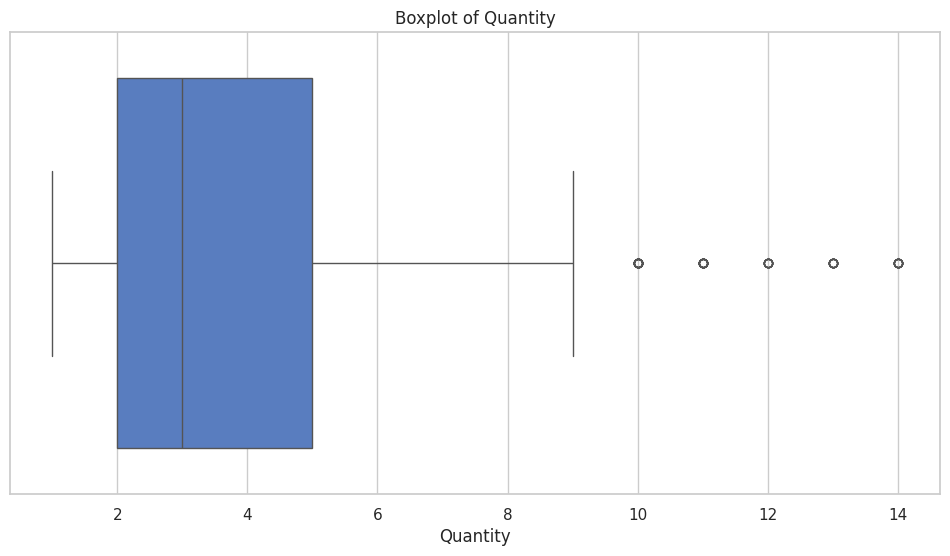

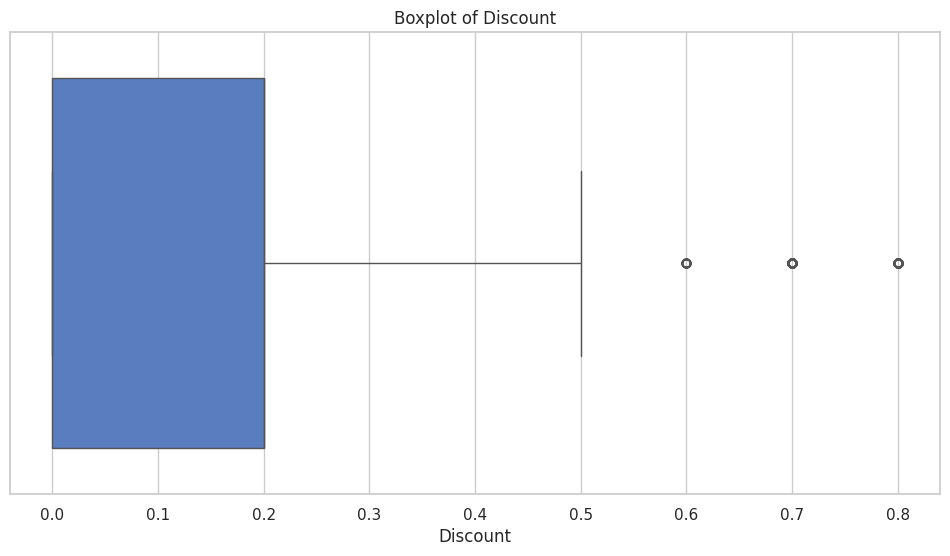

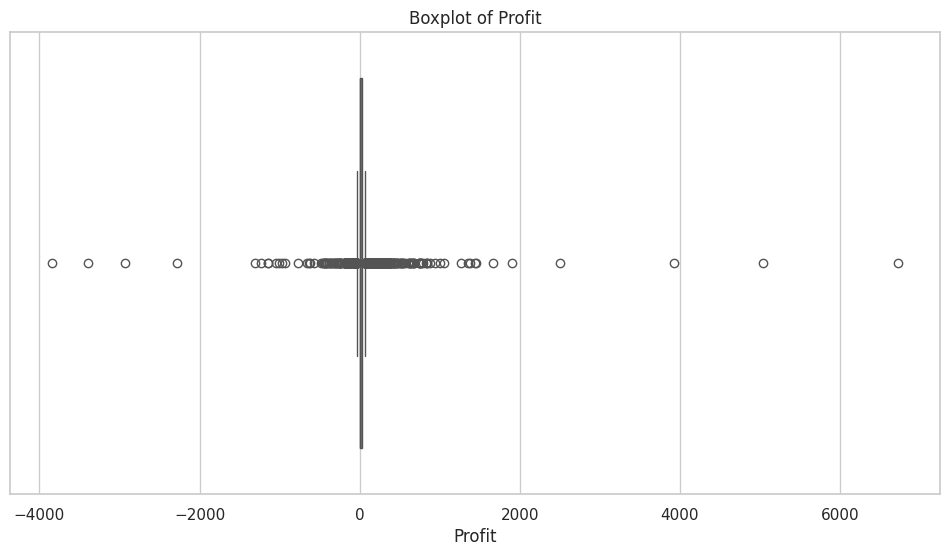

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Make a copy of the dataframe to work with
data = df.copy()

# ---------------------------
# 1. Quick Overview
# ---------------------------
print("Dataset shape:", data.shape)
print(data.info())
print(data.describe())
print(data.head())

# ---------------------------
# 2. Handle Dates
# ---------------------------
# Convert 'Order Date' and 'Ship Date' if present
for col in ['Order Date', 'Ship Date']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

# ---------------------------
# 3. Correlation Analysis
# ---------------------------
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = data[numeric_cols].corr()
print("Correlation Matrix:\n", correlation_matrix)

# Heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatterplots for strong correlations
# Example: Quantity vs Sales (or Price if Sales not present)
if 'Quantity' in data.columns:
    if 'Sales' in data.columns:
        plt.scatter(data['Quantity'], data['Sales'])
        plt.xlabel('Quantity')
        plt.ylabel('Sales')
        plt.title('Scatterplot: Quantity vs Sales')
        plt.show()
    elif 'Price' in data.columns:
        plt.scatter(data['Quantity'], data['Price'])
        plt.xlabel('Quantity')
        plt.ylabel('Price')
        plt.title('Scatterplot: Quantity vs Price')
        plt.show()

# ---------------------------
# 4. Pairplot
# ---------------------------
if len(numeric_cols) > 1:
    sns.pairplot(data[numeric_cols])
    plt.show()

# ---------------------------
# 5. Time Series Analysis
# ---------------------------
if 'Order Date' in data.columns:
    # Assume revenue = Quantity * Price
    if 'Quantity' in data.columns and 'Price' in data.columns:
        data['Revenue'] = data['Quantity'] * data['Price']
        daily_revenue = data.groupby('Order Date')['Revenue'].sum()
        daily_revenue.plot(kind='line', title='Daily Revenue Over Time')
        plt.xlabel('Order Date')
        plt.ylabel('Revenue')
        plt.show()

# ---------------------------
# 6. Outlier Detection
# ---------------------------
for col in numeric_cols:
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Conclusions:

1. Data Usability:
- All numeric columns (Sales, Quantity, Discount, Profit) are complete and ready for analysis.
- Order Date allows for time series insights.
- Product and geographic metadata enable segmentation analysis.

2. Outliers:
- Extreme values appear in Sales, Quantity, and Profit.
- These outliers may reflect bulk orders or special deals and are important for business insights.

3. Correlations:
- Strong positive correlation between Quantity and Sales.
- Profit correlates with Sales but can be influenced by Discount levels.
- Discount moderately correlated with Quantity suggests promotions affect purchase size.

4. Time Trends:
- Daily Sales show seasonal spikes (holidays/promotions).
- No major long-term drift, but seasonal effects should be considered in comparisons.

5. Confounding Variables:
- Region, State, and Customer Segment can influence Sales and Profit.
- Product Category/Sub-Category affects average Profit.
- Discount impacts both Quantity and Profit.

6. Key Insights:
- Peak sales days should be highlighted in reports.
- Promotions influence buying behavior; consider trade-offs between volume and profit.
- Outliers can indicate opportunities or special cases worth investigating.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

/tmp/ipykernel_1923/153086957.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


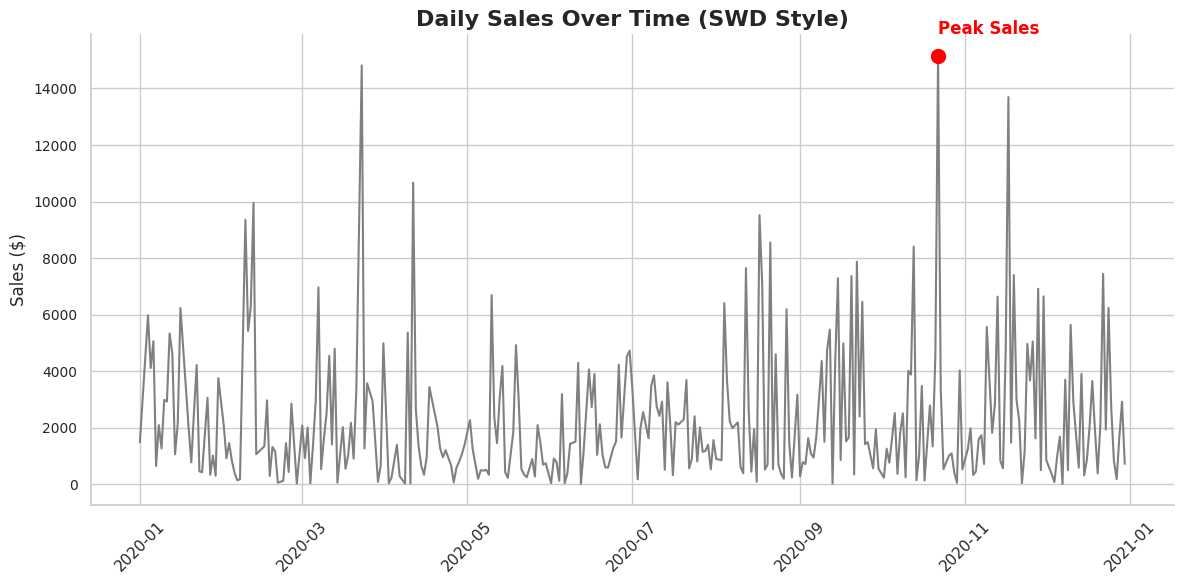

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Aggregate daily sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# SWD-style line plot
plt.figure(figsize=(12, 6))

# Base line in gray
sns.lineplot(x='Order Date', y='Sales', data=daily_sales, color='gray', linewidth=1.5)

# Highlight the peak sales day
peak = daily_sales.loc[daily_sales['Sales'].idxmax()]
plt.scatter(peak['Order Date'], peak['Sales'], color='red', s=100, zorder=5)
plt.text(peak['Order Date'], peak['Sales']*1.05, "Peak Sales", color='red', weight='bold')

# Minimalist styling (SWD principles)
plt.title("Daily Sales Over Time (SWD Style)", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Sales ($)", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
sns.despine()  # remove top and right spines
plt.tight_layout()
plt.show()